In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import tensorflow as tf

from tensorflow.keras.layers import Embedding, Dense, Flatten, Dropout # type: ignore
from tensorflow.keras.models import Sequential # type: ignore

from keras import preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences # type: ignore
from tensorflow.keras import regularizers # type: ignore


In [3]:
from keras.datasets import imdb

In [4]:
max_features = 1000

np.load.__defaults__=(None, True, True, 'ASCII')
importlib.reload(np)

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

c:\Users\one\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py:131: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  _bootstrap._exec(spec, module)


In [5]:
for i, x in enumerate(x_train[0:3]):
    print(f"Sequence: {i}")
    print(x)

Sequence: 0
[1, 14, 22, 16, 43, 530, 973, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 2, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]
Sequence: 1
[1, 194, 2, 194, 2, 78, 228, 5, 6, 2, 2, 2, 134, 26, 4, 715, 8, 118, 2, 14, 394, 20, 13, 119, 954, 189, 1

In [6]:
print(y_train[0:5])

[1 0 0 1 0]


In [7]:
word_index = imdb.get_word_index()

In [8]:
REVERSE_LOOKUP = {value: key for key, value in word_index.items()}

In [9]:
REVERSE_LOOKUP

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [10]:
def get_reviews(x):
    return ' '.join([REVERSE_LOOKUP[index] for index in x])

In [11]:
get_reviews(x_train[0])

"the as you with out themselves powerful and and their becomes and had and of lot from anyone to have after out atmosphere never more room and it so heart shows to years of every never going and help moments or of every and and movie except her was several of enough more with is now and film as you of and and unfortunately of you than him that with out themselves her get for was and of you movie sometimes movie that with scary but and to story wonderful that in seeing in character to of and and with heart had and they of here that with her serious to have does when from why what have and they is you that isn't one will very to as itself with other and in of seen over and for anyone of and br and to whether from than out themselves history he name half some br of and and was two most of mean for 1 any an and she he should is thought and but of script you not while history he heart to real at and but when from one bit then have two of script their with her and most that with wasn't to wi

In [12]:
for i , x in enumerate(x_train[0:3]):
    print(f"length {i} of sampel {len(x)}")

length 0 of sampel 218
length 1 of sampel 189
length 2 of sampel 141


In [13]:
maxlen = 20
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen= maxlen)

In [14]:
x_test.shape

(25000, 20)

In [15]:
x_train.shape

(25000, 20)

In [16]:
model = Sequential()
model.add(Embedding(10000, 8, input_length=20))
model.add(Flatten())

c:\Users\one\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(x_train, y_train, epochs=10, batch_size=30, validation_split=0.2)

Epoch 1/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.6220 - loss: 0.6662 - val_acc: 0.6882 - val_loss: 0.6177
Epoch 2/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.7243 - loss: 0.5579 - val_acc: 0.7198 - val_loss: 0.5454
Epoch 3/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.7495 - loss: 0.5049 - val_acc: 0.7294 - val_loss: 0.5287
Epoch 4/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.7613 - loss: 0.4856 - val_acc: 0.7356 - val_loss: 0.5271
Epoch 5/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.7690 - loss: 0.4744 - val_acc: 0.7332 - val_loss: 0.5294
Epoch 6/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.7774 - loss: 0.4653 - val_acc: 0.7336 - val_loss: 0.5294
Epoch 7/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.7807 - loss: 0.4571 - val_acc: 0.7302 - val_loss: 0.5342
Epoch 8/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.7857 - loss: 0.4494 - val_acc: 0.7300 - val_loss: 0.5353
Epoch 9/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - ac

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 8)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,324 (626.27 KB)

 Trainable params: 80,161 (313.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 80,163 (313.14 KB)

In [21]:
model.save("classifier.keras")

In [ ]:
def display_metrics(history, save = False, save_path = 'results.png'):
    n = len(history.history['loss'])

    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(range(n), (history.history['loss']), 'r', label='Train Loss')
    ax.plot(range(n), history.history['val_loss'], 'b', label='Validation Loss')
    ax.legend(loc='lower right')
    ax.set_title('Loss over iterations')

    ax = fig.add_subplot(1, 2, 2)
    ax.plot(range(n), (history.history['acc']), 'r', label='Train Acc')
    ax.plot(range(n), (history.history['val_acc']), 'b', label='Train Acc')

    ax.legend(loc='lower right')
    ax.set_title('Accuracy over iterations')

    if save:
        plt.savefig(save_path)

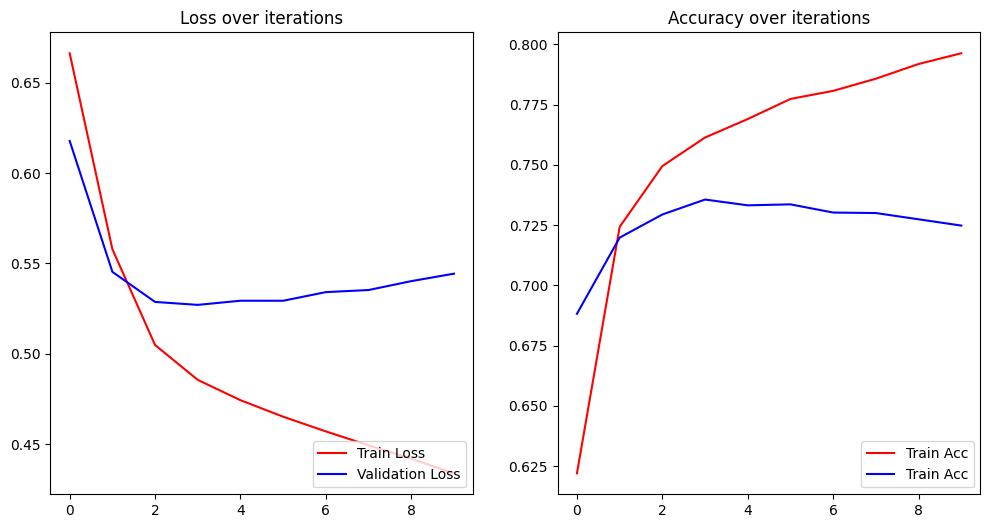

In [ ]:
display_metrics(history, save=True, save_path='./results/results1.png')

In [24]:
p_yx = model.predict(x_test[0:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


In [25]:
def rotten_tomato_score(p_yx):
    return ['rotten' if p <= 0.5 else 'fresh' for p in p_yx]

In [26]:
rotten_tomato_score(p_yx)

['fresh',
 'fresh',
 'rotten',
 'fresh',
 'fresh',
 'rotten',
 'rotten',
 'rotten',
 'rotten',
 'fresh']

In [27]:
weights= model.layers[0].get_weights()[0]

In [28]:
weights.shape

(10000, 8)

In [29]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2)
X_embedded = tsne.fit_transform(weights)

In [30]:
model = Sequential()
model.add(Embedding(10000, 8, input_length=20))
model.add(Flatten())

c:\Users\one\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
model.add(Dense(500, activation='relu'))
model.add(Dense(250, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_test, epochs=10, batch_size=30, validation_split=0.2)

Epoch 1/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.4947 - loss: 0.6937 - val_acc: 0.4932 - val_loss: 0.6938
Epoch 2/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.5535 - loss: 0.6852 - val_acc: 0.5102 - val_loss: 0.6999
Epoch 3/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.6152 - loss: 0.6530 - val_acc: 0.5080 - val_loss: 0.7279
Epoch 4/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.6593 - loss: 0.6173 - val_acc: 0.5008 - val_loss: 0.7463
Epoch 5/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.6999 - loss: 0.5740 - val_acc: 0.4988 - val_loss: 0.8351
Epoch 6/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.7538 - loss: 0.5082 - val_acc: 0.5050 - val_loss: 0.8941
Epoch 7/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8151 - loss: 0.4128 - val_acc: 0.5092 - val_loss: 0.9935
Epoch 8/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8681 - loss: 0.3182 - val_acc: 0.5068 - val_loss: 1.1884
Epoch 9/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

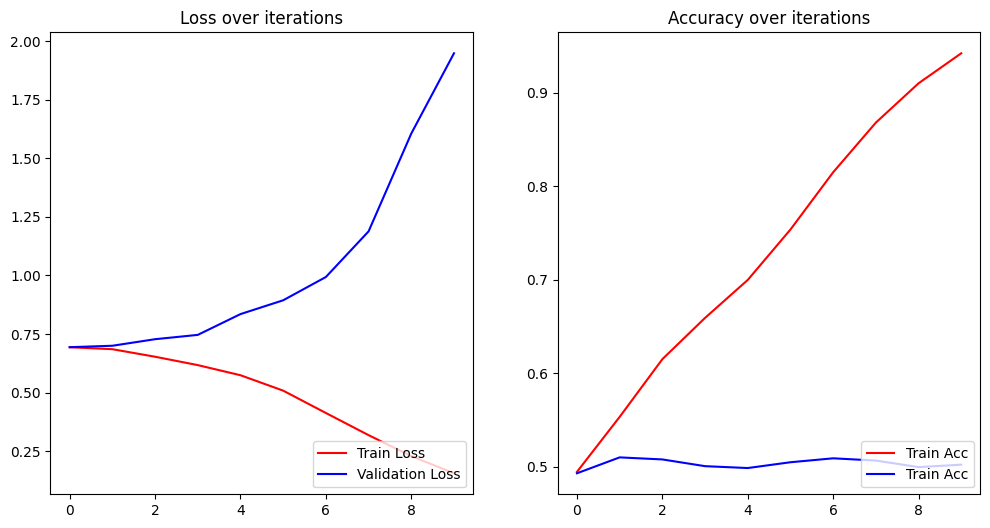

In [34]:
display_metrics(history)

Epoch 1/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.5017 - loss: 0.8090 - val_acc: 0.4894 - val_loss: 0.6933
Epoch 2/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4992 - loss: 0.6932 - val_acc: 0.4894 - val_loss: 0.6933
Epoch 3/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.4991 - loss: 0.6932 - val_acc: 0.4894 - val_loss: 0.6933
Epoch 4/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.4972 - loss: 0.6932 - val_acc: 0.4894 - val_loss: 0.6935
Epoch 5/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.5034 - loss: 0.6932 - val_acc: 0.4894 - val_loss: 0.6933
Epoch 6/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.5010 - loss: 0.6932 - val_acc: 0.4894 - val_loss: 0.6937
Epoch 7/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.5011 - loss: 0.6932 - val_acc: 0.5106 - val_loss: 0.6931
Epoch 8/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.5063 - loss: 0.6932 - val_acc: 0.4894 - val_loss: 0.6932
Epoch 9/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - ac

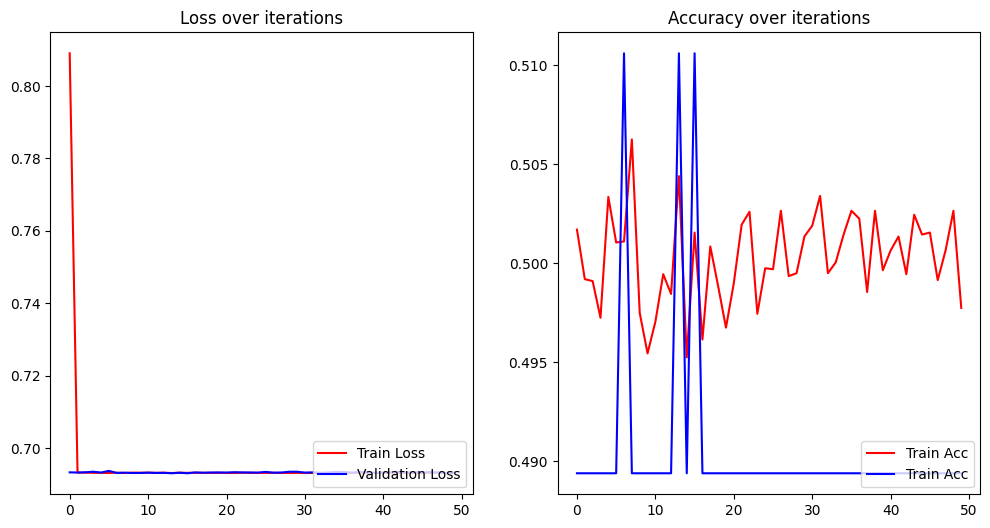

In [ ]:
model = Sequential()
model.add(Embedding(10000, 8, input_length=20))
model.add(Flatten())

model.add(Dense(500, activation='relu', kernel_regularizer=regularizers.L2(l2=5e-3)))
model.add(Dropout(.4))

model.add(Dense(250, activation='relu', kernel_regularizer=regularizers.L2(l2=5e-3)))
model.add(Dropout(.3))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_test, epochs=50, batch_size=30, validation_split=0.2)

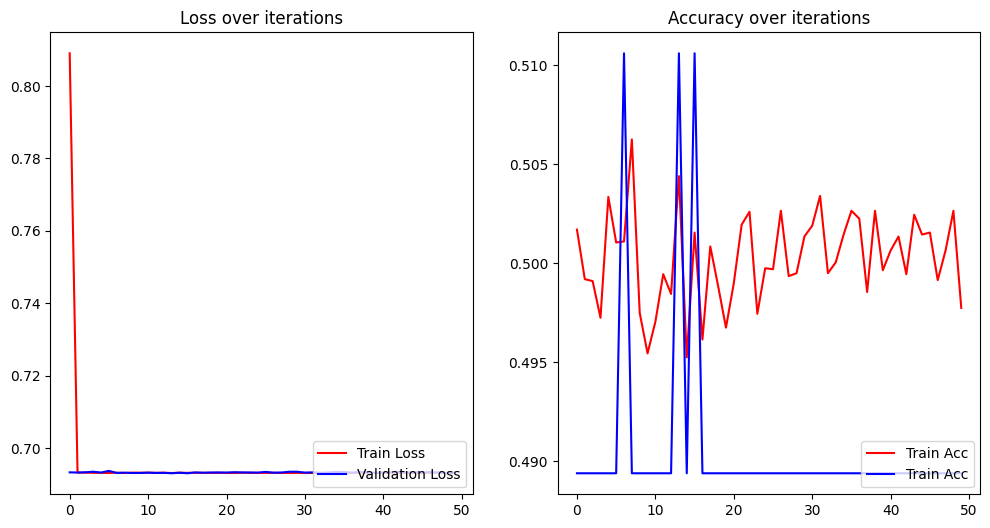

In [ ]:
display_metrics(history, save=True, save_path='./results/results2.png')

In [ ]:
model.save('./models/classifier.keras')